## Module 4 — Statistical & Predictive Layer

This is where your first classification model goes, plus cohort visualization and CLV estimation.

1 — Connect and pull the cohort data (from Query 1)

In [1]:
import pandas as pd
import numpy as np
import os
from urllib.parse import quote_plus
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

load_dotenv()
password_encoded = quote_plus(os.getenv('DB_PASSWORD'))
db_url = f"postgresql://{os.getenv('DB_USER')}:{password_encoded}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
engine = create_engine(db_url)

cohort_query = """
WITH customer_cohort AS (
    SELECT customer_key, DATE_TRUNC('month', first_purchase_date) AS cohort_month
    FROM dim_customer WHERE customer_key != -1
),
customer_activity AS (
    SELECT DISTINCT f.customer_key, DATE_TRUNC('month', d.full_date) AS activity_month
    FROM fact_sales f JOIN dim_date d ON f.date_key = d.date_key
    WHERE f.customer_key != -1 AND f.is_return = FALSE
),
cohort_activity AS (
    SELECT cc.cohort_month, ca.customer_key,
        EXTRACT(YEAR FROM AGE(ca.activity_month, cc.cohort_month)) * 12 +
        EXTRACT(MONTH FROM AGE(ca.activity_month, cc.cohort_month)) AS month_offset
    FROM customer_cohort cc JOIN customer_activity ca ON cc.customer_key = ca.customer_key
)
SELECT cohort_month, month_offset, COUNT(DISTINCT customer_key) AS active_customers
FROM cohort_activity GROUP BY cohort_month, month_offset ORDER BY cohort_month, month_offset;
"""

cohort_data = pd.read_sql(cohort_query, engine)
print(cohort_data.shape)
cohort_data.head()

(325, 3)


,cohort_month,month_offset,active_customers
0,2009-12-01,0.0,955
1,2009-12-01,1.0,355
2,2009-12-01,2.0,338
3,2009-12-01,3.0,431
4,2009-12-01,4.0,388


2 — Pivot into a proper retention matrix and visualize as a heatmap

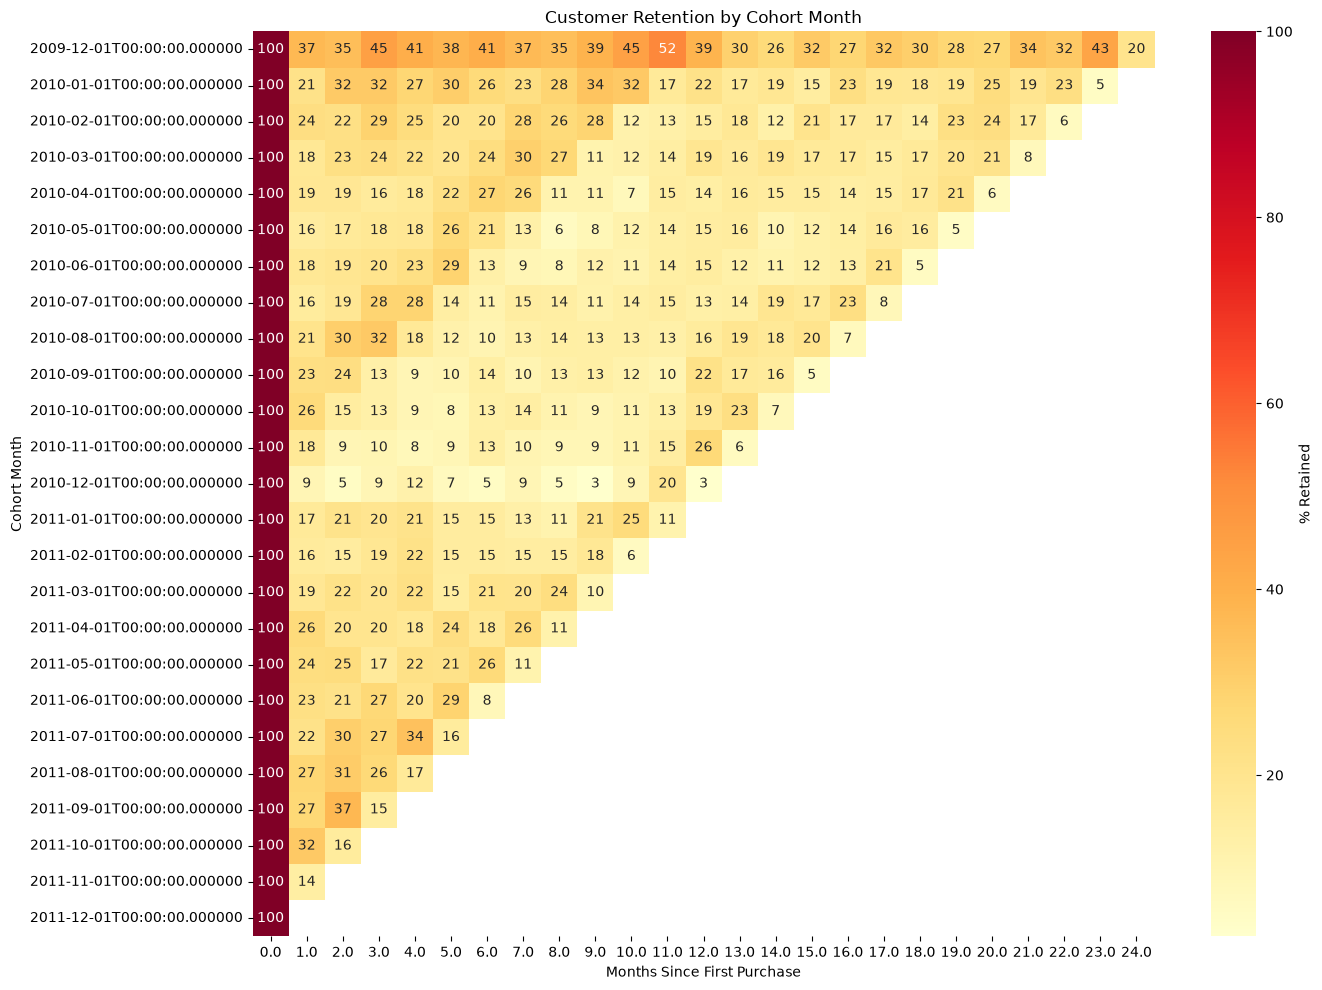

In [2]:
cohort_pivot = cohort_data.pivot(index="cohort_month", columns="month_offset", values="active_customers")

# Convert to retention PERCENTAGE (month 0 = 100% by definition, since that's the cohort's first purchase month)
cohort_size = cohort_pivot[0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(retention_matrix, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax, cbar_kws={"label": "% Retained"})
ax.set_title("Customer Retention by Cohort Month")
ax.set_xlabel("Months Since First Purchase")
ax.set_ylabel("Cohort Month")
plt.tight_layout()
plt.savefig("../outputs/cohort_retention_heatmap.png", dpi=150)
plt.show()

3 — Customer Lifetime Value (simple approach)

In [3]:
clv_query = """
SELECT
    f.customer_key,
    dc.first_purchase_date,
    COUNT(DISTINCT f.invoice_number) AS num_orders,
    SUM(f.total_amount) AS total_spent,
    MAX(dd.full_date) - MIN(dd.full_date) AS customer_lifespan_days
FROM fact_sales f
JOIN dim_customer dc ON f.customer_key = dc.customer_key
JOIN dim_date dd ON f.date_key = dd.date_key
WHERE f.customer_key != -1 AND f.is_return = FALSE
GROUP BY f.customer_key, dc.first_purchase_date;
"""

clv_df = pd.read_sql(clv_query, engine)
clv_df["avg_order_value"] = clv_df["total_spent"] / clv_df["num_orders"]

# Simple CLV estimate: average order value x purchase frequency x an assumed retention-adjusted lifespan
# (documented as a simplified approach, not a full probabilistic CLV model like BG/NBD)
print(clv_df[["num_orders", "total_spent", "avg_order_value"]].describe())

        num_orders    total_spent  avg_order_value
count  5878.000000    5878.000000      5878.000000
mean      6.289384    3018.616737       391.726538
std      13.009406   14737.731040      1215.071054
min       1.000000       2.950000         2.950000
25%       1.000000     348.762500       181.652500
50%       3.000000     898.915000       285.070500
75%       7.000000    2307.090000       420.570000
max     398.000000  608821.650000     84236.250000


4 — Churn Classification (your first classifier)

In [4]:
snapshot_date = pd.read_sql("SELECT MAX(full_date) AS max_date FROM dim_date;", engine)["max_date"].iloc[0]

rfm_features_query = """
SELECT
    f.customer_key,
    MAX(dd.full_date) AS last_purchase_date,
    COUNT(DISTINCT f.invoice_number) AS frequency,
    SUM(f.total_amount) AS monetary,
    AVG(f.total_amount) AS avg_transaction_value
FROM fact_sales f
JOIN dim_date dd ON f.date_key = dd.date_key
WHERE f.customer_key != -1 AND f.is_return = FALSE
GROUP BY f.customer_key;
"""

features_df = pd.read_sql(rfm_features_query, engine)
features_df["last_purchase_date"] = pd.to_datetime(features_df["last_purchase_date"])
features_df["recency_days"] = (pd.to_datetime(snapshot_date) - features_df["last_purchase_date"]).dt.days

# Label: churned if no purchase in the last 90 days
features_df["churned"] = (features_df["recency_days"] > 90).astype(int)

print(f"Churn rate: {features_df['churned'].mean():.1%}")
print(features_df[["frequency", "monetary", "avg_transaction_value", "recency_days", "churned"]].describe())

Churn rate: 50.9%
         frequency       monetary  avg_transaction_value  recency_days  \
count  5878.000000    5878.000000            5878.000000   5878.000000   
mean      6.289384    3018.616737              48.299996    200.866791   
std      13.009406   14737.731040             780.177864    209.353961   
min       1.000000       2.950000               2.042182      0.000000   
25%       1.000000     348.762500              11.470705     25.000000   
50%       3.000000     898.915000              17.354064     95.000000   
75%       7.000000    2307.090000              24.195021    379.000000   
max     398.000000  608821.650000           56157.500000    738.000000   

           churned  
count  5878.000000  
mean      0.508506  
std       0.499970  
min       0.000000  
25%       0.000000  
50%       1.000000  
75%       1.000000  
max       1.000000  


5 — train/test split and the classifier itself

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Recency is used to DEFINE churn, so it can't also be a predictive feature (that would be circular/leaky)
X = features_df[["frequency", "monetary", "avg_transaction_value"]]
y = features_df["churned"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.59      0.66       722
           1       0.67      0.81      0.73       748

    accuracy                           0.70      1470
   macro avg       0.71      0.70      0.69      1470
weighted avg       0.71      0.70      0.70      1470


Confusion Matrix:
[[424 298]
 [144 604]]


In [6]:
import pandas as pd

coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)
print(coefficients)

                 feature  coefficient
0              frequency    -2.721748
1               monetary    -0.415820
2  avg_transaction_value     0.063112


Save the model artifacts and write these customer segments/churn scores back to the warehouse, since dim_customer.customer_segment was left as a placeholder in Module 1's design specifically for this:

In [7]:
features_df["churn_probability"] = model.predict_proba(scaler.transform(X))[:, 1]

features_df["risk_segment"] = pd.cut(
    features_df["churn_probability"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

print(features_df["risk_segment"].value_counts())

risk_segment
High Risk      2569
Medium Risk    2182
Low Risk       1127
Name: count, dtype: int64


Write this back to PostgreSQL as a new table (keeping dim_customer itself untouched, since re-running the ETL script would wipe any manual edits to it):

In [8]:
features_df[["customer_key", "recency_days", "frequency", "monetary", "churn_probability", "risk_segment"]].to_sql(
    "customer_churn_scores", engine, if_exists="replace", index=False
)
print("Saved customer_churn_scores table to warehouse")

Saved customer_churn_scores table to warehouse


In [9]:
retention_matrix.to_csv("../outputs/retention_matrix.csv")